In [1]:
!pip install numpy pandas matplotlib scikit-learn

  Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)

   ---------------------------------------- 0/3 [contourpy]
   ------------- -------------------------- 1/3 [scikit-learn]
   ------------- -------------------------- 1/3 [scikit-learn]
   ------------- -------------------------- 1/3 [scikit-learn]
   ------------- -------------------------- 1/3 [scikit-learn]
   ------------- -------------------------- 1/3 [scikit-learn]
   ------------- -------------------------- 1/3 [scikit-learn]
   ------------- -------------------------- 1/3 [scikit-learn]
   ------------- -------------------------- 1/3 [scikit-learn]
   -------

  ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
0    M001  RandomForest           120000      96.2                45   
1    M002       XGBoost            95000      91.5                80   
2    M003           CNN           150000      98.1               120   
3    M004          LSTM           210000      94.6                95   
4    M005           SVM            85000      88.2                40   

   DataDrift  CPUUsage  PredictionConfidence  FailureRisk  
0          2        42                  0.98            0  
1          8        60                  0.91            0  
2          3        75                  0.99            0  
3          6        68                  0.95            0  
4         18        38                  0.84            1  

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -

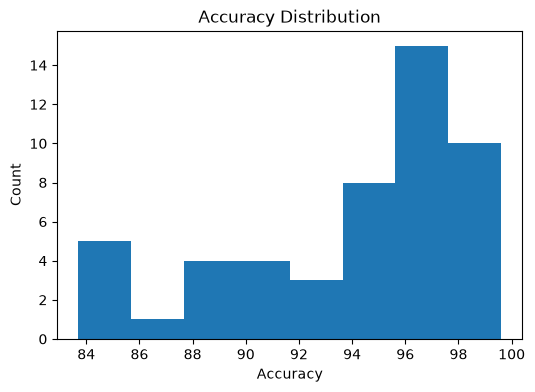

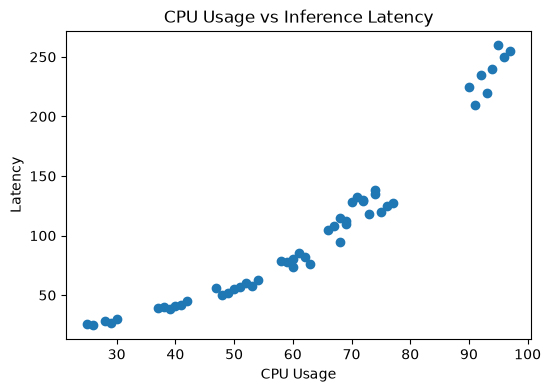

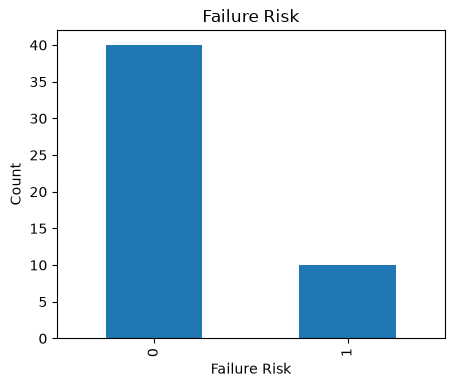


Accuracy Score
1.0

Confusion Matrix
[[8 0]
 [0 2]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



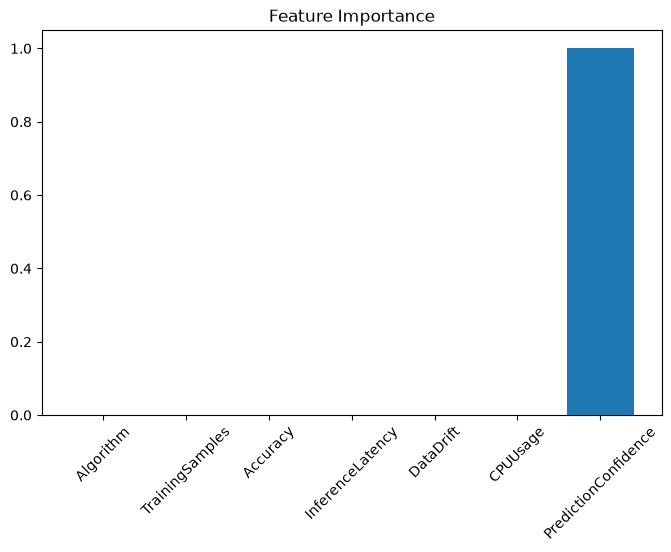


Business Recommendations
--------------------------------
1. Reduce high inference latency before deployment.
2. Monitor data drift regularly.
3. Improve prediction confidence of models.
4. Optimize CPU usage for better performance.
5. Continuously monitor AI models after deployment.


In [46]:
# AI Model Health Monitoring & Failure Risk Prediction

# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1 : Create Dataset

data = {
"ModelID":[
"M001","M002","M003","M004","M005","M006","M007","M008","M009","M010",
"M011","M012","M013","M014","M015","M016","M017","M018","M019","M020",
"M021","M022","M023","M024","M025","M026","M027","M028","M029","M030",
"M031","M032","M033","M034","M035","M036","M037","M038","M039","M040",
"M041","M042","M043","M044","M045","M046","M047","M048","M049","M050"
],

"Algorithm":[
"RandomForest","XGBoost","CNN","LSTM","SVM",
"DecisionTree","Transformer","RandomForest","CNN","XGBoost",
"LSTM","Transformer","SVM","RandomForest","CNN",
"XGBoost","DecisionTree","LSTM","Transformer","CNN",
"RandomForest","XGBoost","CNN","Transformer","SVM",
"DecisionTree","RandomForest","CNN","LSTM","Transformer",
"RandomForest","CNN","XGBoost","LSTM","SVM",
"Transformer","DecisionTree","RandomForest","CNN","XGBoost",
"LSTM","Transformer","CNN","RandomForest","SVM",
"DecisionTree","XGBoost","Transformer","CNN","RandomForest"
],

"TrainingSamples":[
120000,95000,150000,210000,85000,
60000,300000,140000,175000,98000,
225000,315000,90000,132000,182000,
110000,72000,250000,330000,165000,
128000,103000,194000,280000,88000,
64000,145000,180000,240000,350000,
150000,190000,100000,260000,92000,
340000,70000,155000,205000,115000,
270000,360000,170000,149000,87000,
62000,108000,320000,185000,142000
],

"Accuracy":[
96.2,91.5,98.1,94.6,88.2,
84.5,99.1,95.8,97.3,90.8,
95.2,99.4,89.3,94.8,96.7,
92.4,83.9,95.9,99.5,97.0,
95.1,91.2,97.8,99.0,87.6,
84.2,95.7,97.5,96.0,99.2,
95.5,97.2,91.0,95.8,88.5,
99.1,83.7,95.6,97.4,92.1,
95.9,99.6,96.8,94.9,88.8,
84.0,91.8,99.3,97.1,95.3
],

"InferenceLatency":[
45,80,120,95,40,
30,210,55,130,85,
110,260,42,60,125,
78,28,108,240,135,
58,82,118,225,38,
25,52,132,105,250,
63,128,76,115,41,
235,26,50,138,74,
112,255,127,57,39,
27,79,220,129,56
],

"DataDrift":[
2,8,3,6,18,
25,1,4,5,10,
7,0,20,6,3,
9,27,5,1,4,
6,8,2,1,19,
26,5,4,6,0,
3,2,9,5,18,
1,28,4,5,10,
6,0,4,5,21,
25,9,1,3,4
],

"CPUUsage":[
42,60,75,68,38,
30,91,50,72,61,
69,95,41,52,76,
59,28,67,94,74,
53,62,73,90,39,
26,49,71,66,96,
54,70,63,68,40,
92,25,48,74,60,
69,97,77,51,37,
29,58,93,72,47
],

"PredictionConfidence":[
0.98,0.91,0.99,0.95,0.84,
0.80,0.99,0.97,0.98,0.90,
0.96,0.99,0.85,0.95,0.98,
0.92,0.79,0.96,0.99,0.98,
0.95,0.91,0.98,0.99,0.83,
0.81,0.96,0.97,0.95,0.99,
0.96,0.98,0.90,0.96,0.84,
0.99,0.78,0.95,0.98,0.91,
0.96,0.99,0.97,0.95,0.85,
0.80,0.92,0.99,0.98,0.96
],

"FailureRisk":[
0,0,0,0,1,
1,0,0,0,0,
0,0,1,0,0,
0,1,0,0,0,
0,0,0,0,1,
1,0,0,0,0,
0,0,0,0,1,
0,1,0,0,0,
0,0,0,0,1,
1,0,0,0,0
]
}

# Create DataFrame

df = pd.DataFrame(data)

print(df.head())

# Step 2 : Basic Information

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# Step 3 : Convert Algorithm into Numbers

encoder = LabelEncoder()

df["Algorithm"] = encoder.fit_transform(df["Algorithm"])

# Step 4 : Data Visualization

# Accuracy

plt.figure(figsize=(6,4))
plt.hist(df["Accuracy"], bins=8)
plt.title("Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.show()

# CPU Usage

plt.figure(figsize=(6,4))
plt.scatter(df["CPUUsage"], df["InferenceLatency"])
plt.title("CPU Usage vs Inference Latency")
plt.xlabel("CPU Usage")
plt.ylabel("Latency")
plt.show()

# Failure Risk Count

plt.figure(figsize=(5,4))
df["FailureRisk"].value_counts().plot(kind="bar")
plt.title("Failure Risk")
plt.xlabel("Failure Risk")
plt.ylabel("Count")
plt.show()


# Step 5 : Select Features

X = df.drop(["ModelID","FailureRisk"], axis=1)

y = df["FailureRisk"]

# Step 6 : Split Dataset


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 7 : Train Model

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

# Step 8 : Prediction

y_pred = model.predict(X_test)

# Step 9 : Evaluation

print("\nAccuracy Score")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Step 10 : Feature Importance


importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

# Step 11 : Business Recommendations

print("\nBusiness Recommendations")
print("--------------------------------")
print("1. Reduce high inference latency before deployment.")
print("2. Monitor data drift regularly.")
print("3. Improve prediction confidence of models.")
print("4. Optimize CPU usage for better performance.")
print("5. Continuously monitor AI models after deployment.")

In [3]:
#1. Convert all Numerical Columns into NumPy Arrays
training_samples = df["TrainingSamples"].to_numpy()
accuracy = df["Accuracy"].to_numpy()
latency = df["InferenceLatency"].to_numpy()
data_drift = df["DataDrift"].to_numpy()
cpu_usage = df["CPUUsage"].to_numpy()
prediction_confidence = df["PredictionConfidence"].to_numpy()

print("NumPy arrays created successfully.\n")


NumPy arrays created successfully.



In [ ]:
#2.Display the shape, size, dimensions, and data type of each NumPy array. 
arrays = {
    "TrainingSamples": training_samples,
    "Accuracy": accuracy,
    "InferenceLatency": latency,
    "DataDrift": data_drift,
    "CPUUsage": cpu_usage,
    "PredictionConfidence": prediction_confidence
}

for name, array in arrays.items():
    print(name)
    print("Shape :", array.shape)
    print("Size :", array.size)
    print("Dimensions :", array.ndim)
    print("Data Type :", array.dtype)
    print()


TrainingSamples
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64

Accuracy
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : float64

InferenceLatency
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64

DataDrift
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64

CPUUsage
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64

PredictionConfidence
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : float64



In [ ]:
#3.Calculate the mean, median, variance, and standard deviation of the Accuracy column. 
print("Accuracy Statistics")
print("Mean :", np.mean(accuracy))
print("Median :", np.median(accuracy))
print("Variance :", np.var(accuracy))
print("Standard Deviation :", np.std(accuracy))

Accuracy Statistics
Mean : 94.058
Median : 95.65
Variance : 21.235635999999996
Standard Deviation : 4.608213970726619


In [6]:
#4.Find the maximum and minimum values of InferenceLatency. 
print("\nInference Latency")
print("Maximum Latency :", np.max(latency))
print("Minimum Latency :", np.min(latency))


Inference Latency
Maximum Latency : 260
Minimum Latency : 25


In [7]:
#5. Identify all models with CPUUsage greater than 90%. 
print("\nModels with CPU Usage greater than 90%")
high_cpu = df[cpu_usage > 90]
print(high_cpu[["ModelID", "CPUUsage"]])



Models with CPU Usage greater than 90%
   ModelID  CPUUsage
6     M007        91
11    M012        95
18    M019        94
29    M030        96
35    M036        92
41    M042        97
47    M048        93


In [9]:
#6. Find models where DataDrift is greater than 20%. 
print("\nModels with Data Drift greater than 20%")

high_drift = df[data_drift > 20]

print(high_drift[["ModelID", "DataDrift"]])


Models with Data Drift greater than 20%
   ModelID  DataDrift
5     M006         25
16    M017         27
25    M026         26
36    M037         28
44    M045         21
45    M046         25


In [10]:
#7.Normalize the TrainingSamples column using Min-Max normalization with NumPy. 
normalized_training = (
    (training_samples - np.min(training_samples)) /
    (np.max(training_samples) - np.min(training_samples))
)

print("\nNormalized Training Samples")
print(normalized_training)



Normalized Training Samples
[0.2        0.11666667 0.3        0.5        0.08333333 0.
 0.8        0.26666667 0.38333333 0.12666667 0.55       0.85
 0.1        0.24       0.40666667 0.16666667 0.04       0.63333333
 0.9        0.35       0.22666667 0.14333333 0.44666667 0.73333333
 0.09333333 0.01333333 0.28333333 0.4        0.6        0.96666667
 0.3        0.43333333 0.13333333 0.66666667 0.10666667 0.93333333
 0.03333333 0.31666667 0.48333333 0.18333333 0.7        1.
 0.36666667 0.29666667 0.09       0.00666667 0.16       0.86666667
 0.41666667 0.27333333]


In [11]:
#8.Create a NumPy array representing an AI Health Score using: 
health_score = accuracy + (prediction_confidence * 100) - data_drift
print("\nAI Health Score")
print(health_score)



AI Health Score
[192.2 174.5 194.1 183.6 154.2 139.5 197.1 188.8 190.3 170.8 184.2 198.4
 154.3 183.8 191.7 175.4 135.9 186.9 197.5 191.  184.1 174.2 193.8 197.
 151.6 139.2 186.7 190.5 185.  198.2 188.5 193.2 172.  186.8 154.5 197.1
 133.7 186.6 190.4 173.1 185.9 198.6 189.8 184.9 152.8 139.  174.8 197.3
 192.1 187.3]


In [12]:
#Pandas
#9. Convert the dataset into a Pandas DataFrame. 
df = pd.DataFrame(data)
print("DataFrame Created Successfully")
print(df.head())

DataFrame Created Successfully
  ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
0    M001  RandomForest           120000      96.2                45   
1    M002       XGBoost            95000      91.5                80   
2    M003           CNN           150000      98.1               120   
3    M004          LSTM           210000      94.6                95   
4    M005           SVM            85000      88.2                40   

   DataDrift  CPUUsage  PredictionConfidence  FailureRisk  
0          2        42                  0.98            0  
1          8        60                  0.91            0  
2          3        75                  0.99            0  
3          6        68                  0.95            0  
4         18        38                  0.84            1  


In [13]:
#10. Display the first 10 and last 10 records. 
print("\nFirst 10 Records")
print(df.head(10))
print("\nLast 10 Records")
print(df.tail(10))


First 10 Records
  ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
0    M001  RandomForest           120000      96.2                45   
1    M002       XGBoost            95000      91.5                80   
2    M003           CNN           150000      98.1               120   
3    M004          LSTM           210000      94.6                95   
4    M005           SVM            85000      88.2                40   
5    M006  DecisionTree            60000      84.5                30   
6    M007   Transformer           300000      99.1               210   
7    M008  RandomForest           140000      95.8                55   
8    M009           CNN           175000      97.3               130   
9    M010       XGBoost            98000      90.8                85   

   DataDrift  CPUUsage  PredictionConfidence  FailureRisk  
0          2        42                  0.98            0  
1          8        60                  0.91            0  
2        

In [14]:
#11. Display dataset information using info(). 
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ModelID               50 non-null     str    
 1   Algorithm             50 non-null     str    
 2   TrainingSamples       50 non-null     int64  
 3   Accuracy              50 non-null     float64
 4   InferenceLatency      50 non-null     int64  
 5   DataDrift             50 non-null     int64  
 6   CPUUsage              50 non-null     int64  
 7   PredictionConfidence  50 non-null     float64
 8   FailureRisk           50 non-null     int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 3.6 KB
None


In [15]:
#12. Generate descriptive statistics using describe(). 
print("\nDescriptive Statistics")
print(df.describe())


Descriptive Statistics
       TrainingSamples   Accuracy  InferenceLatency  DataDrift   CPUUsage  \
count        50.000000  50.000000         50.000000   50.00000  50.000000   
mean     172120.000000  94.058000        104.160000    8.08000  61.820000   
std       85728.722594   4.654999         67.930144    7.98427  20.029254   
min       60000.000000  83.700000         25.000000    0.00000  25.000000   
25%      100750.000000  91.275000         52.750000    3.00000  48.250000   
50%      150000.000000  95.650000         83.500000    5.00000  62.500000   
75%      221250.000000  97.275000        128.750000    9.00000  73.750000   
max      360000.000000  99.600000        260.000000   28.00000  97.000000   

       PredictionConfidence  FailureRisk  
count             50.000000    50.000000  
mean               0.932800     0.200000  
std                0.063569     0.404061  
min                0.780000     0.000000  
25%                0.910000     0.000000  
50%                0.960

In [ ]:
#13. Check for missing values. 
print("Missing Values")
print(df.isnull().sum())



Missing Values
ModelID                 0
Algorithm               0
TrainingSamples         0
Accuracy                0
InferenceLatency        0
DataDrift               0
CPUUsage                0
PredictionConfidence    0
FailureRisk             0
dtype: int64


In [17]:
#14.Check for duplicate records. 
print("\nDuplicate Records")
duplicates = df.duplicated().sum()
print("Total Duplicate Records :", duplicates)


Duplicate Records
Total Duplicate Records : 0


In [18]:
#15. Display the number of models for each algorithm. 
print("\nModels in Each Algorithm")
print(df["Algorithm"].value_counts())



Models in Each Algorithm
Algorithm
CNN             10
RandomForest     9
Transformer      8
XGBoost          7
LSTM             6
SVM              5
DecisionTree     5
Name: count, dtype: int64


In [19]:
#16. Calculate the average accuracy for each algorithm. 
print("\nAverage Accuracy of Each Algorithm")
average_accuracy = df.groupby("Algorithm")["Accuracy"].mean()
print(average_accuracy)


Average Accuracy of Each Algorithm
Algorithm
CNN             97.290000
DecisionTree    84.060000
LSTM            95.566667
RandomForest    95.433333
SVM             88.480000
Transformer     99.275000
XGBoost         91.542857
Name: Accuracy, dtype: float64


In [ ]:
#17. Find the top 10 models with the highest prediction confidence. 
print("Top 10 Models by Prediction Confidence")
top_models = df.sort_values(
    by="PredictionConfidence",
    ascending=False
).head(10)
print(top_models[["ModelID", "Algorithm", "PredictionConfidence"]])



Top 10 Models by Prediction Confidence
   ModelID     Algorithm  PredictionConfidence
6     M007   Transformer                  0.99
2     M003           CNN                  0.99
11    M012   Transformer                  0.99
29    M030   Transformer                  0.99
47    M048   Transformer                  0.99
41    M042   Transformer                  0.99
35    M036   Transformer                  0.99
18    M019   Transformer                  0.99
23    M024   Transformer                  0.99
0     M001  RandomForest                  0.98


In [ ]:
#18. Sort the dataset by InferenceLatency in descending order.
print("Dataset Sorted by Inference Latency")

sorted_df = df.sort_values(
    by="InferenceLatency",
    ascending=False
)

print(sorted_df)



Dataset Sorted by Inference Latency
   ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
11    M012   Transformer           315000      99.4               260   
41    M042   Transformer           360000      99.6               255   
29    M030   Transformer           350000      99.2               250   
18    M019   Transformer           330000      99.5               240   
35    M036   Transformer           340000      99.1               235   
23    M024   Transformer           280000      99.0               225   
47    M048   Transformer           320000      99.3               220   
6     M007   Transformer           300000      99.1               210   
38    M039           CNN           205000      97.4               138   
19    M020           CNN           165000      97.0               135   
27    M028           CNN           180000      97.5               132   
8     M009           CNN           175000      97.3               130   
48    M049    

In [22]:
#19. Create a new column called HealthStatus based on: Healthy, Moderate, Critical 
def health_status(score):

    if score >= 190:
        return "Healthy"

    elif score >= 175:
        return "Moderate"

    else:
        return "Critical"

# Health Score Formula

df["HealthScore"] = (
    df["Accuracy"] +
    (df["PredictionConfidence"] * 100) -
    df["DataDrift"]
)

# Create HealthStatus

df["HealthStatus"] = df["HealthScore"].apply(health_status)

print("\nHealth Status")

print(df[["ModelID", "HealthScore", "HealthStatus"]])



Health Status
   ModelID  HealthScore HealthStatus
0     M001        192.2      Healthy
1     M002        174.5     Critical
2     M003        194.1      Healthy
3     M004        183.6     Moderate
4     M005        154.2     Critical
5     M006        139.5     Critical
6     M007        197.1      Healthy
7     M008        188.8     Moderate
8     M009        190.3      Healthy
9     M010        170.8     Critical
10    M011        184.2     Moderate
11    M012        198.4      Healthy
12    M013        154.3     Critical
13    M014        183.8     Moderate
14    M015        191.7      Healthy
15    M016        175.4     Moderate
16    M017        135.9     Critical
17    M018        186.9     Moderate
18    M019        197.5      Healthy
19    M020        191.0      Healthy
20    M021        184.1     Moderate
21    M022        174.2     Critical
22    M023        193.8      Healthy
23    M024        197.0      Healthy
24    M025        151.6     Critical
25    M026        139.2

In [23]:
#20. Export the processed dataset to a CSV file. 
df.to_csv("AI_Model_Health_Report.csv", index=False)
print("\nDataset exported successfully.")
print("File Name : AI_Model_Health_Report.csv")


Dataset exported successfully.
File Name : AI_Model_Health_Report.csv


In [25]:
#Part C Data Analysis
#21. Calculate the correlation matrix. 
print("Correlation Matrix")
correlation = df.corr(numeric_only=True)
print(correlation)

Correlation Matrix
                      TrainingSamples  Accuracy  InferenceLatency  DataDrift  \
TrainingSamples              1.000000  0.806547          0.916954  -0.718419   
Accuracy                     0.806547  1.000000          0.762794  -0.968185   
InferenceLatency             0.916954  0.762794          1.000000  -0.681309   
DataDrift                   -0.718419 -0.968185         -0.681309   1.000000   
CPUUsage                     0.883132  0.866731          0.946370  -0.823795   
PredictionConfidence         0.738309  0.985874          0.691598  -0.983163   
FailureRisk                 -0.560406 -0.845013         -0.524630   0.924845   
HealthScore                  0.751803  0.988650          0.709564  -0.993351   

                      CPUUsage  PredictionConfidence  FailureRisk  HealthScore  
TrainingSamples       0.883132              0.738309    -0.560406     0.751803  
Accuracy              0.866731              0.985874    -0.845013     0.988650  
InferenceLatency 

In [26]:
#22. Identify the feature most correlated with FailureRisk. 
print("\nFeature Most Correlated with FailureRisk")

failure_correlation = correlation["FailureRisk"].sort_values(ascending=False)

print(failure_correlation)

print("\nHighest Correlated Feature (excluding FailureRisk):")
print(failure_correlation.index[1], ":", failure_correlation.iloc[1])



Feature Most Correlated with FailureRisk
FailureRisk             1.000000
DataDrift               0.924845
InferenceLatency       -0.524630
TrainingSamples        -0.560406
CPUUsage               -0.719187
Accuracy               -0.845013
PredictionConfidence   -0.904182
HealthScore            -0.904543
Name: FailureRisk, dtype: float64

Highest Correlated Feature (excluding FailureRisk):
DataDrift : 0.9248453357990789


In [27]:
#23. Compare average latency for healthy and failed models. 
print("\nAverage Inference Latency")
average_latency = df.groupby("FailureRisk")["InferenceLatency"].mean()
print(average_latency)



Average Inference Latency
FailureRisk
0    121.8
1     33.6
Name: InferenceLatency, dtype: float64


In [28]:
#24. Find the average CPU usage for each algorithm. 
print("\nAverage CPU Usage for Each Algorithm")
average_cpu = df.groupby("Algorithm")["CPUUsage"].mean()
print(average_cpu)



Average CPU Usage for Each Algorithm
Algorithm
CNN             73.400000
DecisionTree    27.600000
LSTM            67.833333
RandomForest    49.555556
SVM             39.000000
Transformer     93.500000
XGBoost         60.428571
Name: CPUUsage, dtype: float64


In [29]:
#25. Find the average prediction confidence for healthy and failed models. 
print("\nAverage Prediction Confidence")
average_confidence = df.groupby("FailureRisk")["PredictionConfidence"].mean()
print(average_confidence)



Average Prediction Confidence
FailureRisk
0    0.96125
1    0.81900
Name: PredictionConfidence, dtype: float64


In [30]:
#26. List models with high accuracy (>95%) but also marked as high failure risk. 
print("\nHigh Accuracy but High Failure Risk")
high_risk_models = df[
    (df["Accuracy"] > 95) &
    (df["FailureRisk"] == 1)
]
print(high_risk_models[[
    "ModelID",
    "Algorithm",
    "Accuracy",
    "FailureRisk"
]])



High Accuracy but High Failure Risk
Empty DataFrame
Columns: [ModelID, Algorithm, Accuracy, FailureRisk]
Index: []


In [31]:
#27. Find the average data drift for every algorithm. 
print("\nAverage Data Drift")
average_drift = df.groupby("Algorithm")["DataDrift"].mean()
print(average_drift)


Average Data Drift
Algorithm
CNN              3.500000
DecisionTree    26.200000
LSTM             5.833333
RandomForest     4.333333
SVM             19.200000
Transformer      0.625000
XGBoost          9.000000
Name: DataDrift, dtype: float64


In [32]:
#28. Identify the top 5 healthiest AI models. 
print("\nTop 5 Healthiest AI Models")
top_healthiest = df.sort_values(
    by="HealthScore",
    ascending=False
).head(5)

print(top_healthiest[[
    "ModelID",
    "Algorithm",
    "HealthScore"
]])


Top 5 Healthiest AI Models
   ModelID    Algorithm  HealthScore
41    M042  Transformer        198.6
11    M012  Transformer        198.4
29    M030  Transformer        198.2
18    M019  Transformer        197.5
47    M048  Transformer        197.3


In [33]:
#29. Identify the top 5 highest-risk AI models.
print("\nTop 5 Highest-Risk AI Models")

highest_risk = df.sort_values(
    by="HealthScore",
    ascending=True
).head(5)

print(highest_risk[[
    "ModelID",
    "Algorithm",
    "HealthScore",
    "FailureRisk"
]])


Top 5 Highest-Risk AI Models
   ModelID     Algorithm  HealthScore  FailureRisk
36    M037  DecisionTree        133.7            1
16    M017  DecisionTree        135.9            1
45    M046  DecisionTree        139.0            1
25    M026  DecisionTree        139.2            1
5     M006  DecisionTree        139.5            1


In [34]:
#30. Write five observations from your analysis. 
print("\nFive Observations")

print("1. Models with higher prediction confidence generally have lower failure risk.")

print("2. Higher inference latency may indicate slower AI model performance.")

print("3. High data drift can negatively affect the health of AI models.")

print("4. Models with lower CPU usage are generally more efficient.")

print("5. Health Score helps identify the best and worst performing AI models.")


Five Observations
1. Models with higher prediction confidence generally have lower failure risk.
2. Higher inference latency may indicate slower AI model performance.
3. High data drift can negatively affect the health of AI models.
4. Models with lower CPU usage are generally more efficient.
5. Health Score helps identify the best and worst performing AI models.


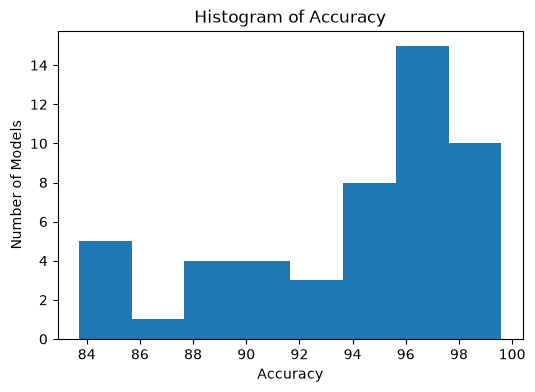

In [35]:
#Part D – Matplotlib
#31. Plot a histogram of Accuracy.
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Accuracy"], bins=8)
plt.title("Histogram of Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Number of Models")

plt.show()

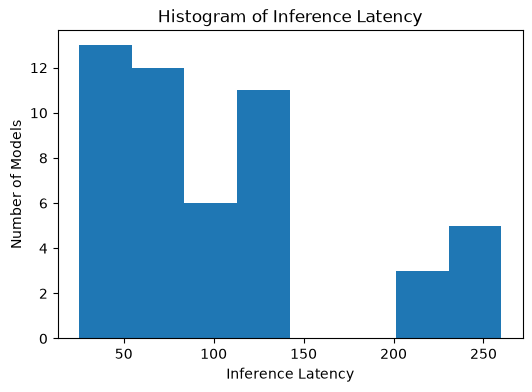

In [36]:
#32. Plot a histogram of InferenceLatency. 
plt.figure(figsize=(6,4))

plt.hist(df["InferenceLatency"], bins=8)

plt.title("Histogram of Inference Latency")
plt.xlabel("Inference Latency")
plt.ylabel("Number of Models")

plt.show()

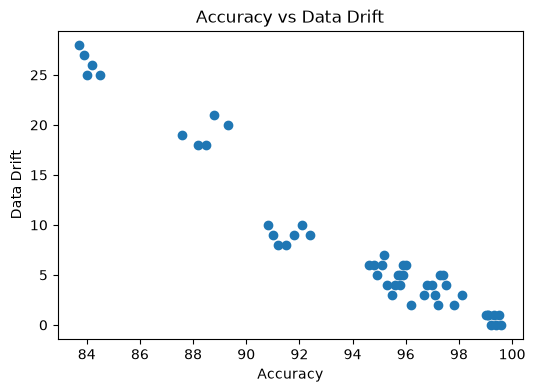

In [37]:
#33. Create a scatter plot of Accuracy vs DataDrift. 
plt.figure(figsize=(6,4))

plt.scatter(df["Accuracy"], df["DataDrift"])

plt.title("Accuracy vs Data Drift")
plt.xlabel("Accuracy")
plt.ylabel("Data Drift")

plt.show()

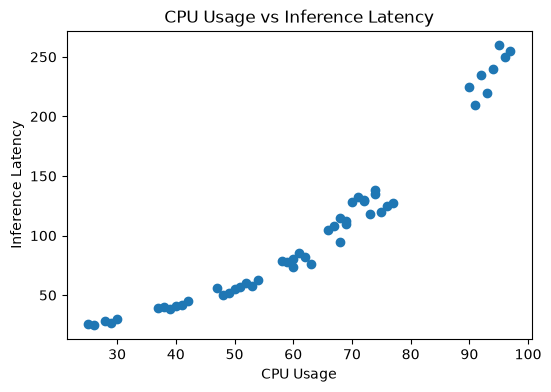

In [ ]:
#34. Scatter Plot of CPU Usage vs Inference Latency
plt.figure(figsize=(6,4))

plt.scatter(df["CPUUsage"], df["InferenceLatency"])

plt.title("CPU Usage vs Inference Latency")
plt.xlabel("CPU Usage")
plt.ylabel("Inference Latency")

plt.show()

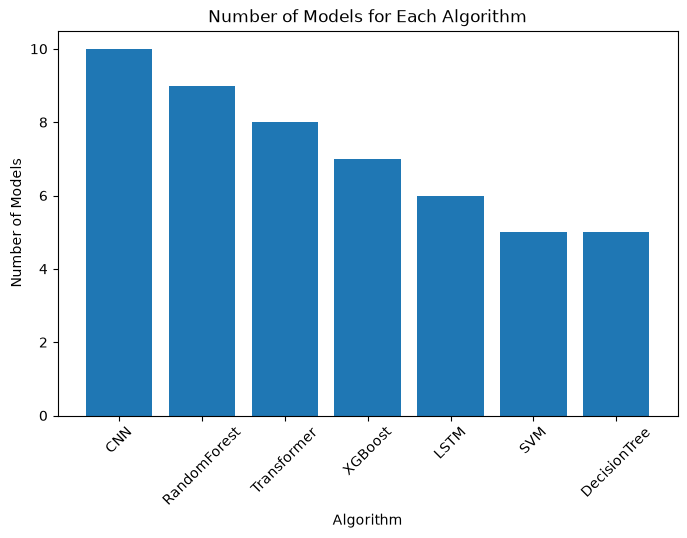

In [39]:
#35. Create a bar chart showing the number of models for each algorithm. 
algorithm_count = df["Algorithm"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(algorithm_count.index, algorithm_count.values)

plt.title("Number of Models for Each Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Number of Models")
plt.xticks(rotation=45)

plt.show()


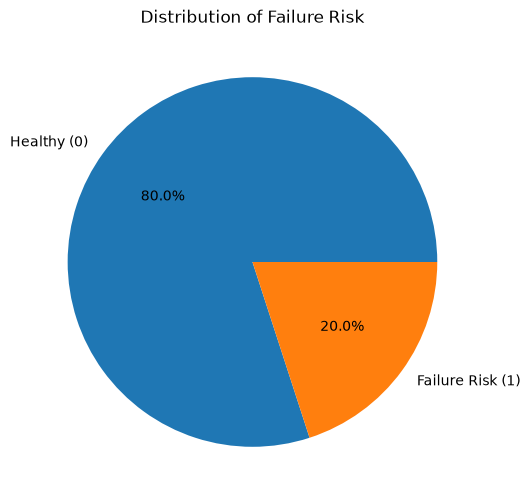

In [40]:
#36. Create a pie chart showing the distribution of FailureRisk. 
failure_count = df["FailureRisk"].value_counts()
plt.figure(figsize=(6,6))

plt.pie(
    failure_count,
    labels=["Healthy (0)", "Failure Risk (1)"],
    autopct="%1.1f%%"
)

plt.title("Distribution of Failure Risk")

plt.show()

In [41]:
#Part E – Scikit-learn 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [42]:
#37 Encode the Algorithm column using LabelEncoder.
encoder = LabelEncoder()

df["Algorithm"] = encoder.fit_transform(df["Algorithm"])

print("Algorithm column encoded successfully.")


Algorithm column encoded successfully.


In [43]:
#38. Split the dataset into training and testing sets using an 80:20 ratio. 
X = df[[
    "Algorithm",
    "TrainingSamples",
    "Accuracy",
    "InferenceLatency",
    "DataDrift",
    "CPUUsage",
    "PredictionConfidence"
]]

y = df["FailureRisk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)


Training Data Shape : (40, 7)
Testing Data Shape : (10, 7)


In [44]:
#39. Train a RandomForestClassifier to predict FailureRisk and evaluate the model using: • Accuracy Score • Confusion Matrix • Classification Report 
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

# Predict

y_pred = model.predict(X_test)

# Accuracy

print("\nAccuracy Score")
print(accuracy_score(y_test, y_pred))

# Confusion Matrix

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy Score
1.0

Confusion Matrix
[[8 0]
 [0 2]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [45]:
#40. Predict the failure risk for the following new AI models and provide a business recommendation for each: 
new_models = pd.DataFrame({

    "Algorithm": ["Transformer", "RandomForest", "CNN"],

    "TrainingSamples": [275000, 135000, 190000],

    "Accuracy": [98.4, 93.8, 96.5],

    "InferenceLatency": [215, 68, 145],

    "DataDrift": [4, 12, 6],

    "CPUUsage": [88, 54, 72],

    "PredictionConfidence": [0.98, 0.92, 0.97]

})

# Encode Algorithm

new_models["Algorithm"] = encoder.transform(new_models["Algorithm"])

# Predict Failure Risk

prediction = model.predict(new_models)

new_models["PredictedFailureRisk"] = prediction

print("\nPrediction Results")
print(new_models)
# Business Recommendation

print("\nBusiness Recommendations")

for i in range(len(new_models)):

    print("\nModel", i + 1)

    if prediction[i] == 0:
        print("Prediction : Healthy")
        print("Recommendation : Model can be deployed. Continue regular monitoring.")

    else:
        print("Prediction : High Failure Risk")
        print("Recommendation : Retrain the model and reduce latency, CPU usage or data drift before deployment.")


Prediction Results
   Algorithm  TrainingSamples  Accuracy  InferenceLatency  DataDrift  \
0          5           275000      98.4               215          4   
1          3           135000      93.8                68         12   
2          0           190000      96.5               145          6   

   CPUUsage  PredictionConfidence  PredictedFailureRisk  
0        88                  0.98                     0  
1        54                  0.92                     0  
2        72                  0.97                     0  

Business Recommendations

Model 1
Prediction : Healthy
Recommendation : Model can be deployed. Continue regular monitoring.

Model 2
Prediction : Healthy
Recommendation : Model can be deployed. Continue regular monitoring.

Model 3
Prediction : Healthy
Recommendation : Model can be deployed. Continue regular monitoring.
